In [65]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

In [66]:
df_snapshot = pd.read_csv('/Users/tyco/Desktop/MADS/sanovo_19052025/data/processed/data_snapshots.csv')

In [67]:
# Convert MerDateDay to datetime if not already done
df_snapshot['MerDate'] = pd.to_datetime(df_snapshot['MerDate'] )

# Filter out weekend dates (Saturday and Sunday)
df_snapshot = df_snapshot[~df_snapshot['MerDate'].dt.weekday.isin([5, 6])]

# create MerDateDay
df_snapshot['MerDateDay'] = df_snapshot['MerDate'].dt.date

In [68]:
df_snapshot['time_in_seconds'] = pd.to_timedelta(df_snapshot['time_delta']).dt.total_seconds()
df_snapshot.head()

,index,MerDate,MerId,MerType,MerNumber,MerSubNumber,MerData1,MerData2,MerData3,MerData4,...,MerText,MerDeviceType,MerDeviceNumber,MerPriority,Error/warnings,lane_stopping_machine,snapshot,time_delta,MerDateDay,time_in_seconds
0,0,2025-01-30 10:21:42,11897186,21,460,12,1.0,22.0,41.0,NaN,...,NaN,0,0,0,21_460_22.0_41.0,NaN,1,0 days 00:04:02,2025-01-30,242.0
1,1,2025-01-30 10:21:56,11897187,23,460,12,0.0,0.0,0.0,NaN,...,NaN,0,0,0,23_460_0.0_0.0,NaN,1,0 days 00:04:02,2025-01-30,242.0
2,2,2025-01-30 10:21:56,11897188,21,460,12,1.0,22.0,41.0,NaN,...,NaN,0,0,0,21_460_22.0_41.0,NaN,1,0 days 00:04:02,2025-01-30,242.0
3,3,2025-01-30 10:21:57,11897189,23,460,12,0.0,0.0,0.0,NaN,...,NaN,0,0,0,23_460_0.0_0.0,NaN,1,0 days 00:04:02,2025-01-30,242.0
4,4,2025-01-30 10:21:57,11897190,21,460,12,1.0,22.0,41.0,NaN,...,NaN,0,0,0,21_460_22.0_41.0,NaN,1,0 days 00:04:02,2025-01-30,242.0


we are going to make a train and test set based on the ordered data from last to most recent datetime

In [69]:
df_snapshot.sort_values('MerDate', ascending=True)
# Calculate the split index for 80% train data
split_index = int(len(df_snapshot) * 0.8)

# Split the data into train and test sets
train = df_snapshot.iloc[:split_index]
test = df_snapshot.iloc[split_index:]

In [70]:
# Define features and target variable
X_train = train[['MerType', 'MerNumber', 'MerSubNumber']]
y_train = train['time_in_seconds']

X_test = test[['MerType', 'MerNumber', 'MerSubNumber']]
y_test = test['time_in_seconds']

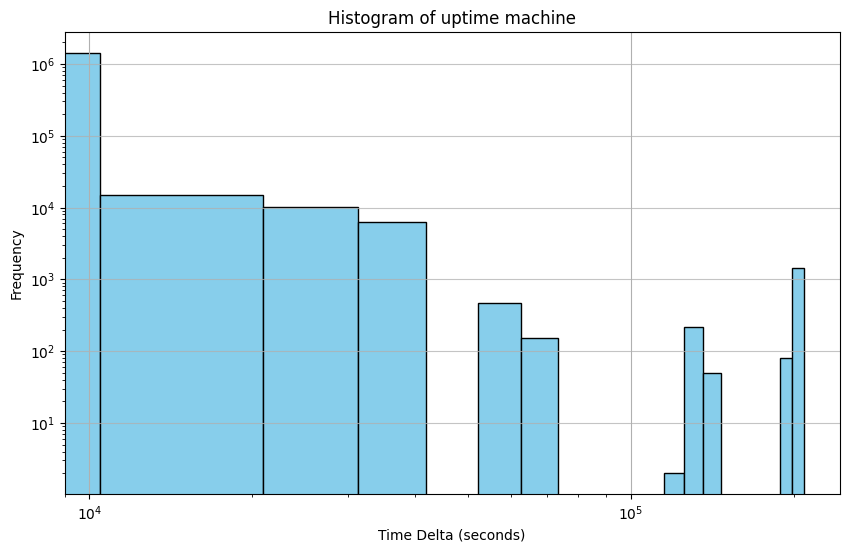

In [71]:
plt.figure(figsize=(10, 6))
train['time_in_seconds'].hist(bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of uptime machine')
plt.xlabel('Time Delta (seconds)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.xscale('log')
plt.yscale('log')
plt.show()

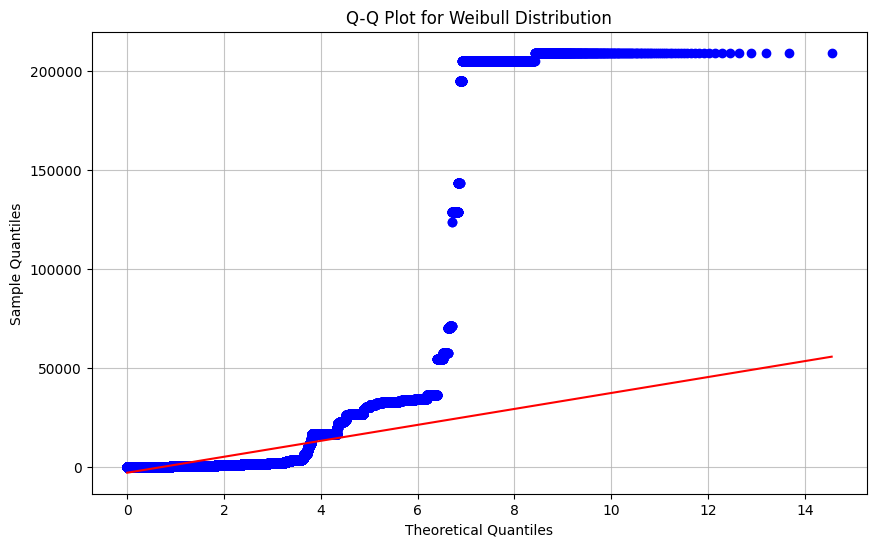

In [72]:
from scipy.stats import probplot

import matplotlib.pyplot as plt

# Generate a Q-Q plot for the Weibull distribution
plt.figure(figsize=(10, 6))
probplot(train['time_in_seconds'], dist="weibull_min", sparams=(1,), plot=plt)
plt.title('Q-Q Plot for Weibull Distribution')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.grid(alpha=0.75)
plt.show()

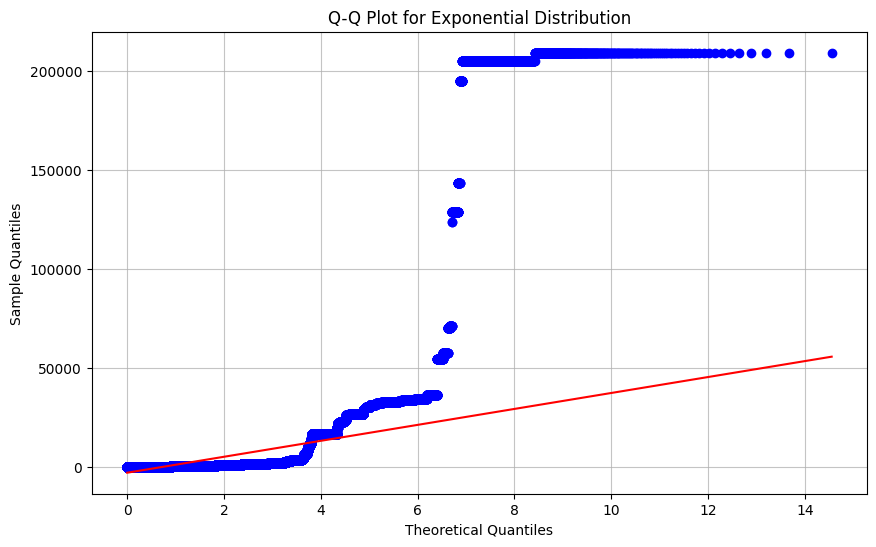

In [73]:
# Generate a Q-Q plot for the Exponential distribution
plt.figure(figsize=(10, 6))
probplot(train['time_in_seconds'], dist="expon", plot=plt)
plt.title('Q-Q Plot for Exponential Distribution')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.grid(alpha=0.75)
plt.show()

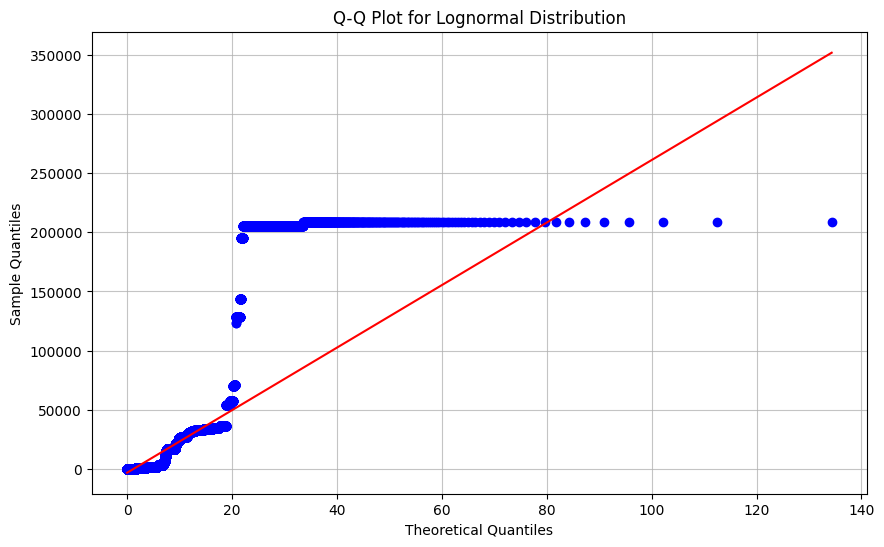

In [74]:
# Generate a Q-Q plot for the Lognormal distribution
plt.figure(figsize=(10, 6))
probplot(train['time_in_seconds'], dist="lognorm", sparams=(1,), plot=plt)
plt.title('Q-Q Plot for Lognormal Distribution')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.grid(alpha=0.75)
plt.show()

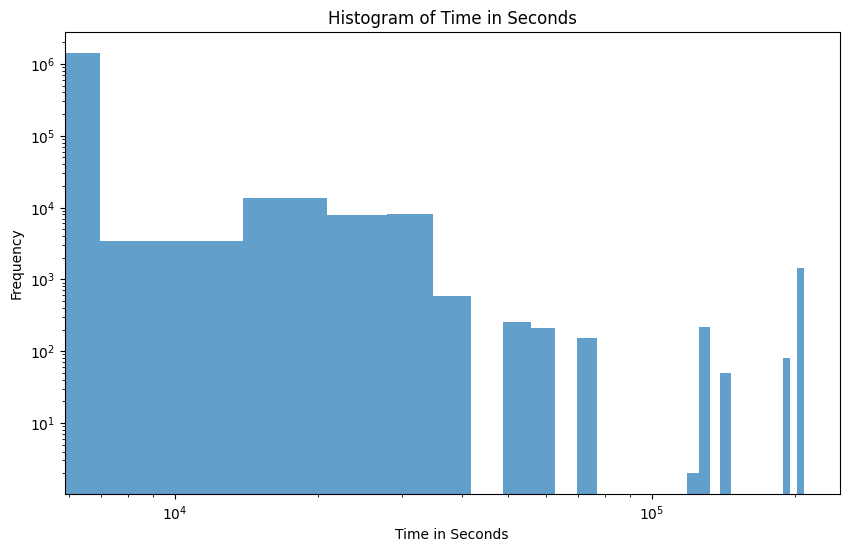

In [75]:
# Create a histogram for the 'time_in_seconds' column
plt.figure(figsize=(10, 6))
train['time_in_seconds'].plot.hist(bins=30, alpha=0.7)
plt.title('Histogram of Time in Seconds')
plt.xlabel('Time in Seconds')
plt.ylabel('Frequency')
plt.xscale('log')
plt.yscale('log')
plt.show()

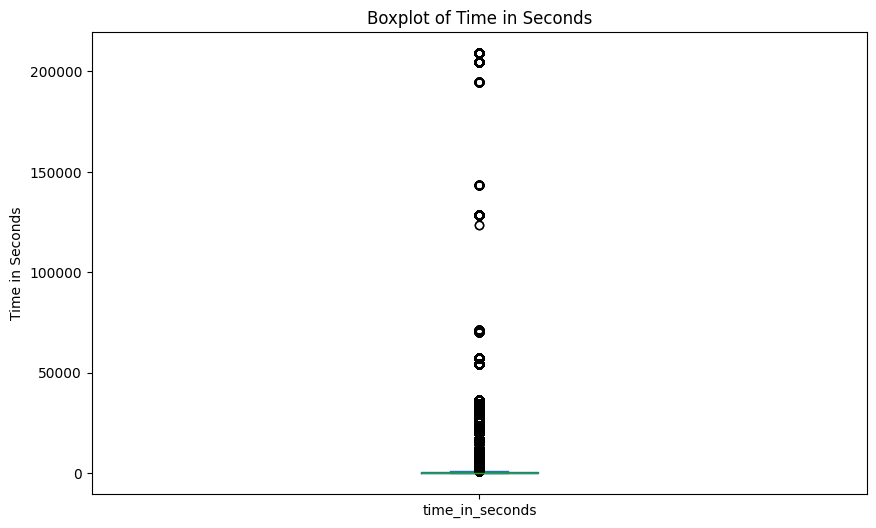

In [76]:
import matplotlib.pyplot as plt

# Create a boxplot for the 'time_in_seconds' column
plt.figure(figsize=(10, 6))
train['time_in_seconds'].plot.box()
plt.title('Boxplot of Time in Seconds')
plt.ylabel('Time in Seconds')
plt.show()

In [77]:
df_snapshot[df_snapshot['snapshot'] == 806]['MerDate'].agg(['min', 'max'])

min   2025-01-31 20:47:02
max   2025-02-03 05:42:14
Name: MerDate, dtype: datetime64[ns]

In [78]:
long_uptime = df_snapshot[df_snapshot['time_in_seconds'] > 100000]

In [79]:
short_uptime = df_snapshot[df_snapshot['time_in_seconds'] < 30]

/var/folders/pt/00xl4yzd64s0vbx9w9tzh94m0000gn/T/ipykernel_15048/3205456412.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  long_agg = long_uptime.groupby('snapshot').apply(


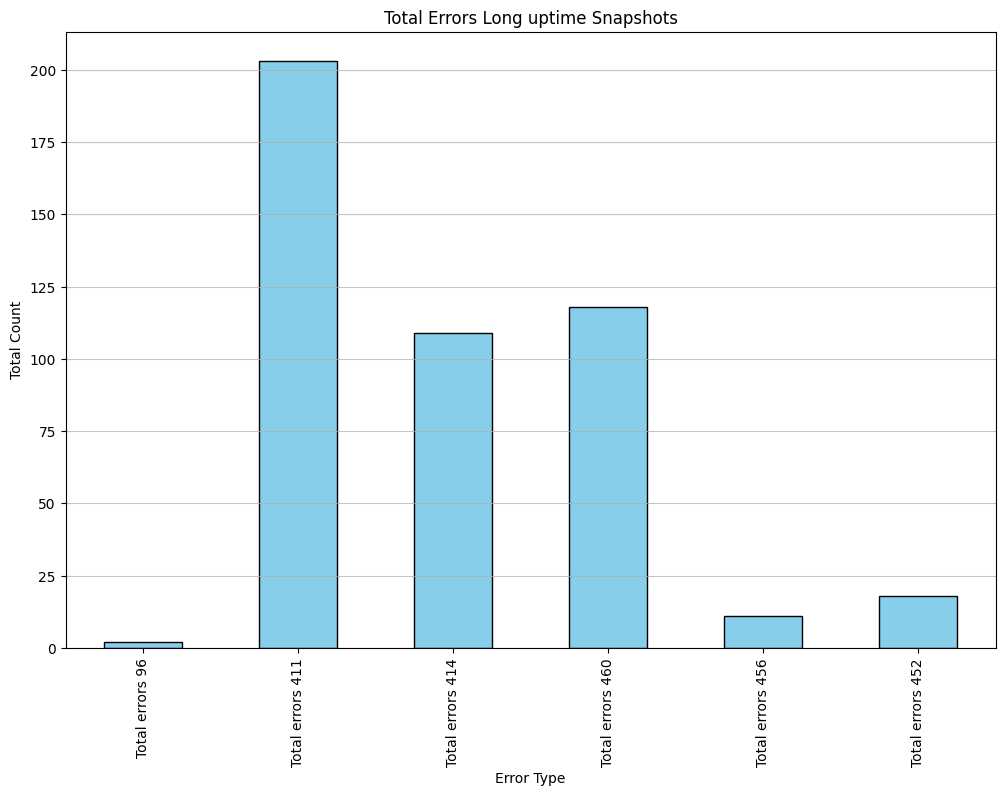

In [80]:
long_agg = long_uptime.groupby('snapshot').apply(
    lambda x: pd.Series({
        'Total errors 96': ((x['MerType'] == 21) & (x['MerNumber'] == 96)).sum(),
        'Total errors 411': ((x['MerType'] == 21) & (x['MerNumber'] == 411)).sum(),
        'Total errors 414': ((x['MerType'] == 21) & (x['MerNumber'] == 414)).sum(),
        'Total errors 460': ((x['MerType'] == 21) & (x['MerNumber'] == 460)).sum(),
        'Total errors 456': ((x['MerType'] == 21) & (x['MerNumber'] == 456)).sum(),
        'Total errors 452': ((x['MerType'] == 21) & (x['MerNumber'] == 452)).sum(),
        'Total stops': ((x['MerType'] == 8) & (x['MerNumber'] == 0)).sum()
    })
)

long_agg.head()

# Create histograms for each error column in long_agg
error_columns = ['Total errors 96', 'Total errors 411', 'Total errors 414', 'Total errors 460', 'Total errors 456', 'Total errors 452']
# Create a bar chart for each error column in long_agg
plt.figure(figsize=(12, 8))
long_agg[error_columns].sum().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Total Errors Long uptime Snapshots')
plt.xlabel('Error Type')
plt.ylabel('Total Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

/var/folders/pt/00xl4yzd64s0vbx9w9tzh94m0000gn/T/ipykernel_15048/2370666595.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  short_agg = short_uptime.groupby('snapshot').apply(


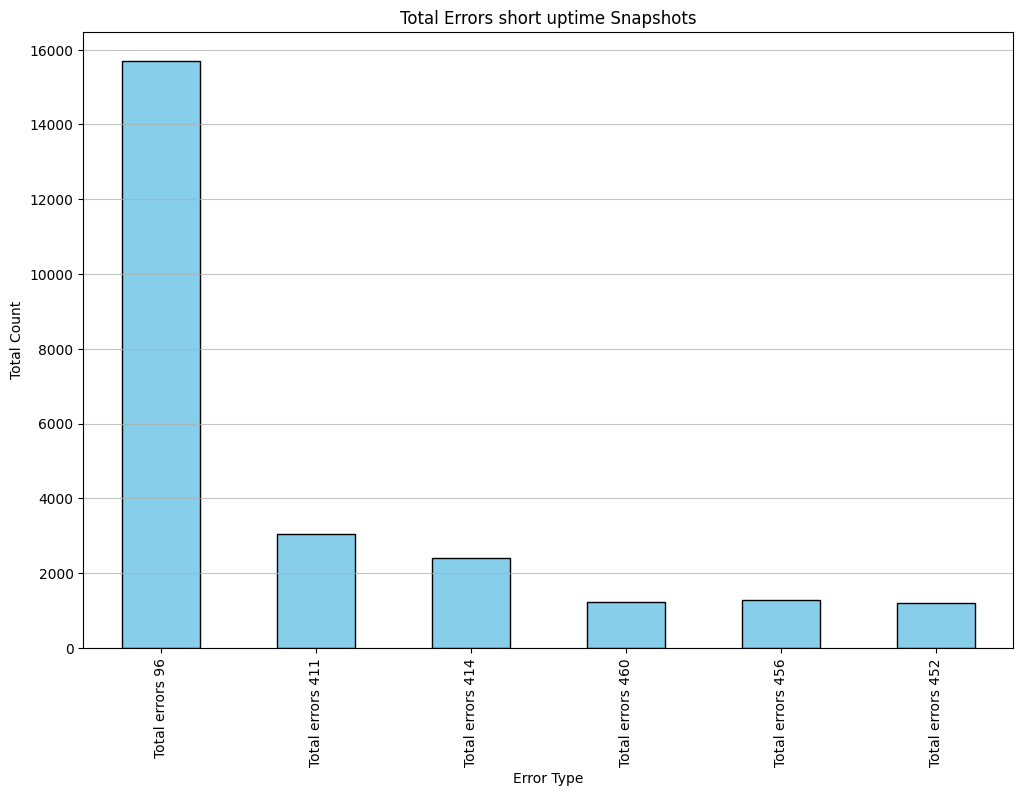

In [81]:
short_agg = short_uptime.groupby('snapshot').apply(
    lambda x: pd.Series({
        'Total errors 96': ((x['MerType'] == 21) & (x['MerNumber'] == 96)).sum(),
        'Total errors 411': ((x['MerType'] == 21) & (x['MerNumber'] == 411)).sum(),
        'Total errors 414': ((x['MerType'] == 21) & (x['MerNumber'] == 414)).sum(),
        'Total errors 460': ((x['MerType'] == 21) & (x['MerNumber'] == 460)).sum(),
        'Total errors 456': ((x['MerType'] == 21) & (x['MerNumber'] == 456)).sum(),
        'Total errors 452': ((x['MerType'] == 21) & (x['MerNumber'] == 452)).sum(),
        'Total stops': ((x['MerType'] == 8) & (x['MerNumber'] == 0)).sum()
    })
)

short_agg.head()

# Create histograms for each error column in long_agg
error_columns = ['Total errors 96', 'Total errors 411', 'Total errors 414', 'Total errors 460', 'Total errors 456', 'Total errors 452']
# Create a bar chart for each error column in long_agg
plt.figure(figsize=(12, 8))
short_agg[error_columns].sum().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Total Errors short uptime Snapshots')
plt.xlabel('Error Type')
plt.ylabel('Total Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [82]:
train = train[['snapshot', 'MerType', 'MerNumber', 'MerSubNumber', 'time_in_seconds']]
train.select_dtypes(include=['float64', 'int64']).columns

Index(['snapshot', 'MerType', 'MerNumber', 'MerSubNumber', 'time_in_seconds'], dtype='object')

In [83]:
train_agg = train.groupby('snapshot').apply(
    lambda x: pd.Series({
        'Total errors 460': ((x['MerType'] == 21) & (x['MerNumber'] == 460)).sum(),
        'Total errors 461': ((x['MerType'] == 21) & (x['MerNumber'] == 461)).sum(),
        'Total errors 452': ((x['MerType'] == 21) & (x['MerNumber'] == 452)).sum(),
        'Total errors 414': ((x['MerType'] == 21) & (x['MerNumber'] == 414)).sum(),
        'Total errors 411': ((x['MerType'] == 21) & (x['MerNumber'] == 411)).sum(),
        'Total errors 456': ((x['MerType'] == 21) & (x['MerNumber'] == 456)).sum(),
        'Total errors 490': ((x['MerType'] == 21) & (x['MerNumber'] == 490)).sum(),
        'Total errors 453': ((x['MerType'] == 21) & (x['MerNumber'] == 453)).sum(),
        'Total errors 458': ((x['MerType'] == 21) & (x['MerNumber'] == 458)).sum(),
        'Total errors 470': ((x['MerType'] == 21) & (x['MerNumber'] == 470)).sum(),
        'Total errors 462': ((x['MerType'] == 21) & (x['MerNumber'] == 462)).sum(),
        'Total errors 412': ((x['MerType'] == 21) & (x['MerNumber'] == 412)).sum(),
        'Total errors 480': ((x['MerType'] == 21) & (x['MerNumber'] == 480)).sum(),
        'Total errors 483': ((x['MerType'] == 21) & (x['MerNumber'] == 483)).sum(),
        'Total errors 415': ((x['MerType'] == 21) & (x['MerNumber'] == 415)).sum(),
        'Total errors 420': ((x['MerType'] == 21) & (x['MerNumber'] == 420)).sum(),
        'Total errors 401': ((x['MerType'] == 21) & (x['MerNumber'] == 401)).sum(),
        'Total errors 454': ((x['MerType'] == 21) & (x['MerNumber'] == 454)).sum(),
        'Total errors 430': ((x['MerType'] == 21) & (x['MerNumber'] == 430)).sum(),
        'Total errors 413': ((x['MerType'] == 21) & (x['MerNumber'] == 413)).sum(),
        'Total errors 451': ((x['MerType'] == 21) & (x['MerNumber'] == 451)).sum(),
        'Total errors 481': ((x['MerType'] == 21) & (x['MerNumber'] == 481)).sum(),
        'Total errors 450': ((x['MerType'] == 21) & (x['MerNumber'] == 450)).sum(),
        'Total errors 421': ((x['MerType'] == 21) & (x['MerNumber'] == 421)).sum(),
        'Total errors 410': ((x['MerType'] == 21) & (x['MerNumber'] == 410)).sum(),
        'Total errors 405': ((x['MerType'] == 21) & (x['MerNumber'] == 405)).sum(),
        'Total errors 455': ((x['MerType'] == 21) & (x['MerNumber'] == 455)).sum(),
        'Total errors 440': ((x['MerType'] == 21) & (x['MerNumber'] == 440)).sum(),
        'Total errors 511': ((x['MerType'] == 21) & (x['MerNumber'] == 511)).sum(),
        'time_in_seconds': x['time_in_seconds'].max()
    })
)

train_agg.head()

/var/folders/pt/00xl4yzd64s0vbx9w9tzh94m0000gn/T/ipykernel_15048/2594423896.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_agg = train.groupby('snapshot').apply(


,Total errors 460,Total errors 461,Total errors 452,Total errors 414,Total errors 411,Total errors 456,Total errors 490,Total errors 453,Total errors 458,Total errors 470,...,Total errors 451,Total errors 481,Total errors 450,Total errors 421,Total errors 410,Total errors 405,Total errors 455,Total errors 440,Total errors 511,time_in_seconds
snapshot,,,,,,,,,,,,,,,,,,,,,
1,8.0,0.0,3.0,2.0,2.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,242.0
2,0.0,0.0,1.0,3.0,3.0,2.0,0.0,0.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,317.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0
4,4.0,0.0,7.0,11.0,9.0,6.0,0.0,0.0,0.0,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,818.0
5,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,76.0


In [86]:
# there are 10 categorial columns and 10 numerical. We are going to transform the categorical to a numerical value. We will create a pipeline for this so we can add extra preprecessing steps very easily.
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

# Apply StandardScaler to all columns
preprocessing = ColumnTransformer(
    transformers=[('num', StandardScaler(), train_agg.columns)]
)


# dimensionality reduction with pca to two dimensions
pca = PCA(n_components=2)


data_prep = make_pipeline(preprocessing, 
                          pca)

processed_data = data_prep.fit_transform(train_agg)

print(processed_data)

[[ 0.79221535 -0.10268177]
 [ 1.3550008   0.20207745]
 [-0.68611693 -0.23920739]
 ...
 [-0.68569319 -0.2394958 ]
 [ 3.36564083  1.88305548]
 [-0.61762091 -0.17105896]]


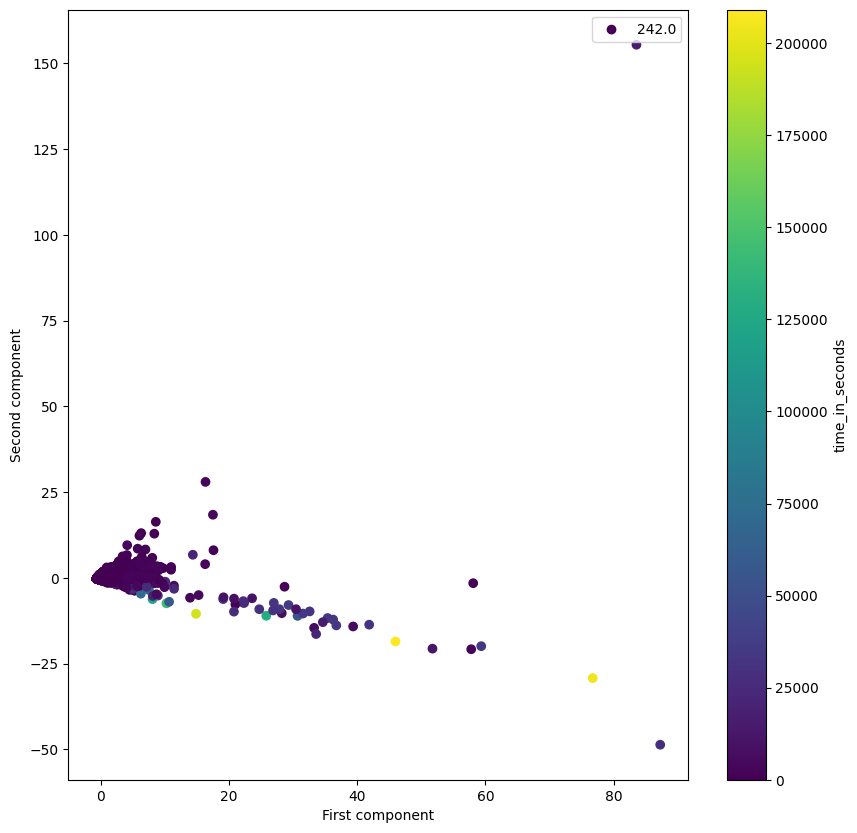

In [87]:
# lets plot the result of the dimension reduction algoritm
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

plt.figure(figsize=(10,10))

scatter = plt.scatter(processed_data[:,0], processed_data[:,1], c=train_agg['time_in_seconds'])
plt.xlabel('First component')
plt.ylabel('Second component')
plt.legend(train_agg['time_in_seconds'])

cbar = plt.colorbar(scatter)
cbar.set_label('time_in_seconds')
plt.show()

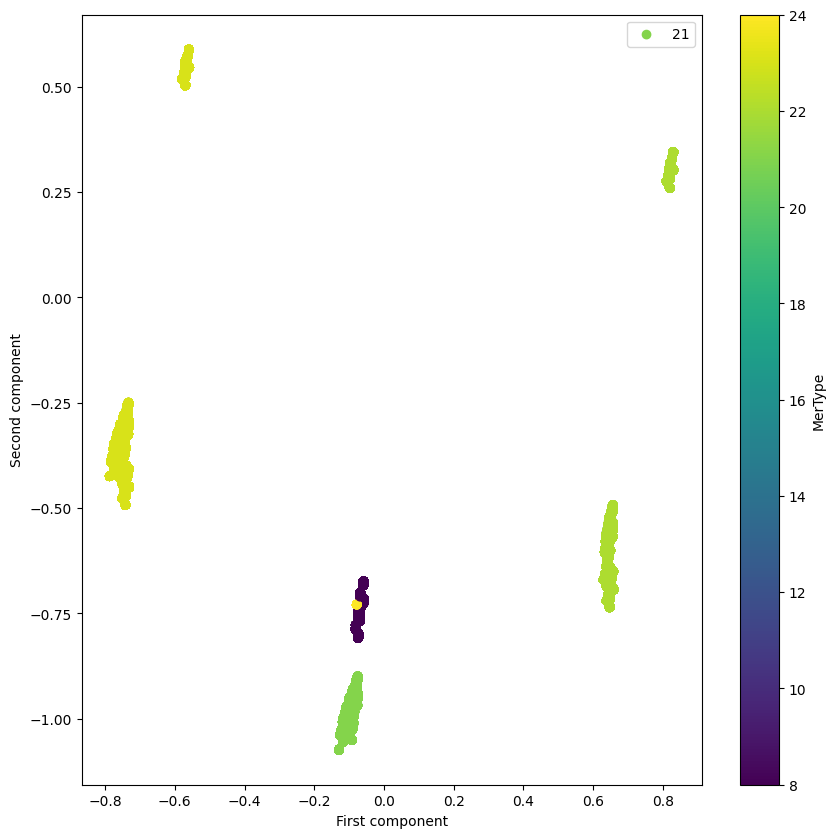

In [47]:
# lets plot the result of the dimension reduction algoritm
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

plt.figure(figsize=(10,10))

scatter = plt.scatter(processed_data[:,0], processed_data[:,1], c=X_train['MerType'])
plt.xlabel('First component')
plt.ylabel('Second component')
plt.legend(X_train['MerType'])

cbar = plt.colorbar(scatter)
cbar.set_label('MerType')
plt.show()